In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
data = pd.read_csv('youtube_ad_revenue_dataset.csv')


In [8]:
data

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811


In [9]:
max_value_ad = data['ad_revenue_usd'].max()
print(max_value_ad)
mx_v= data['subscribers'].max()
print(mx_v)

382.7682540396426
999997


In [10]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [11]:
print("Shape:", data.shape)
print("\nData Types:")
print(data.dtypes)

print("\nMissing Values (%):")
print((data.isnull().mean() * 100).sort_values(ascending=False))

print("\nDuplicate Rows:", data.duplicated().sum())


Shape: (122400, 12)

Data Types:
video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
dtype: object

Missing Values (%):
likes                   4.997549
comments                4.993464
watch_time_minutes      4.987745
video_id                0.000000
date                    0.000000
views                   0.000000
video_length_minutes    0.000000
subscribers             0.000000
category                0.000000
device                  0.000000
country                 0.000000
ad_revenue_usd          0.000000
dtype: float64

Duplicate Rows: 2400


In [12]:
print("Is video_id unique?", data['video_id'].is_unique)
print("Unique videos:", data['video_id'].nunique())


Is video_id unique? False
Unique videos: 5000


In [13]:
data['date'] = pd.to_datetime(data['date'])

# Extract useful components
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['dayofweek'] = data['date'].dt.dayofweek


In [14]:
logical_errors = (
    (data['views'] < 0) |
    (data['likes'] < 0) |
    (data['comments'] < 0) |
    (data['watch_time_minutes'] < 0) |
    (data['video_length_minutes'] < 0) |
    (data['ad_revenue_usd'] < 0) |
    (data['watch_time_minutes'] < data['video_length_minutes'])
)

print("Logical error rows:", logical_errors.sum())


Logical error rows: 0


In [15]:
data = data[~logical_errors].copy()


In [16]:
# Separate columns
numeric_cols = data.select_dtypes(include=np.number).columns
categorical_cols = data.select_dtypes(include='object').columns

# Median imputation for numeric
for col in numeric_cols:
    if data[col].isnull().sum() > 0:
         data[col]=  data[col].fillna(data[col].median())

# Mode / 'Unknown' for categorical
for col in categorical_cols:
    if data[col].isnull().sum() > 0:
        data[col]= data[col].fillna("Unknown")


In [17]:
skewed_cols = ['views', 'subscribers', 'ad_revenue_usd']

for col in skewed_cols:
    data[f'log_{col}'] = np.log1p(data[col])
# Log transformation applied to stabilize scale and improve modeling performance

In [18]:
# Log transformation applied to:
# 1. Reduce scale dominance (views & revenue vary by orders of magnitude)
# 2. Improve numerical stability for linear models
# 3. Align with multiplicative monetization effects


In [19]:
print("Duplicate Rows:", data.duplicated().sum())


Duplicate Rows: 2400


In [20]:
data = data.drop_duplicates()


In [21]:
print("Final shape:", data.shape)
print("Remaining missing values:", data.isnull().sum().sum())
print("Duplicates:", data.duplicated().sum())

Final shape: (120000, 18)
Remaining missing values: 0
Duplicates: 0


# EDA (Exploratory Data Analysis)

### Univariate Analysis

In [22]:
# this was performed earlier in the notebook before the log transformations(howver its a part of EDA so including it here)
numeric_univariate_cols = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'ad_revenue_usd'
]


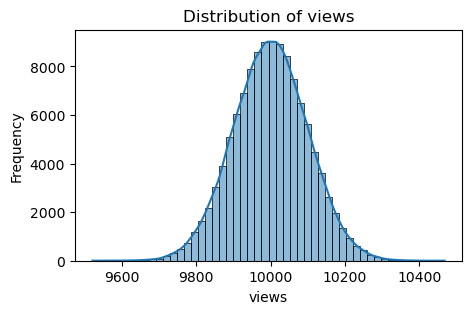

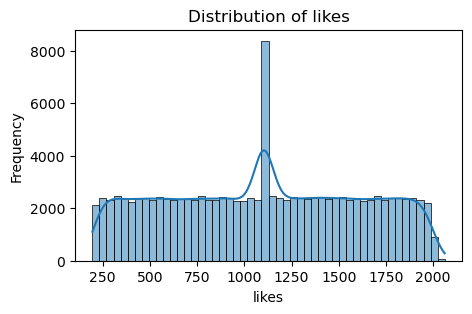

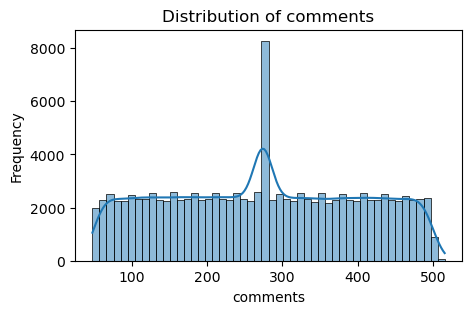

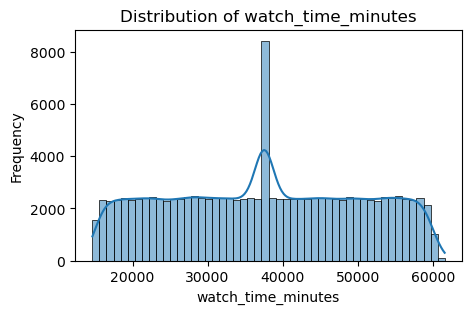

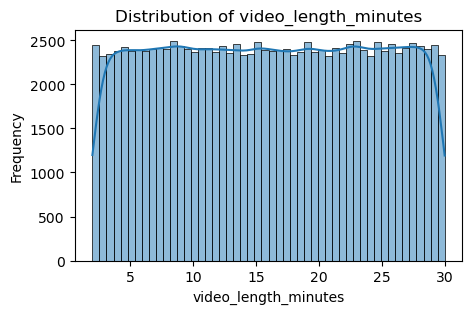

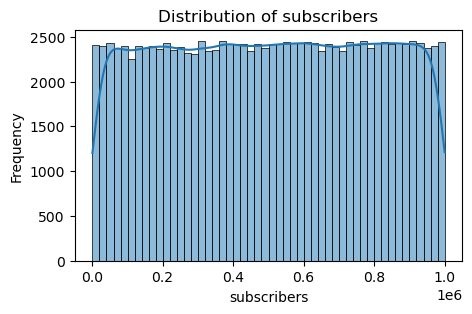

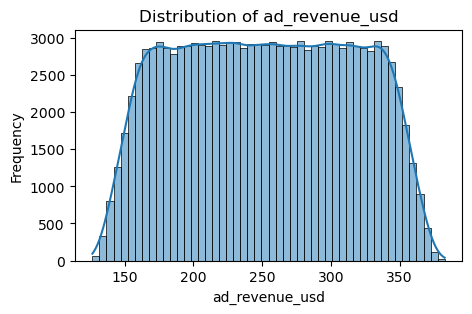

In [23]:
for col in numeric_univariate_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(data[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


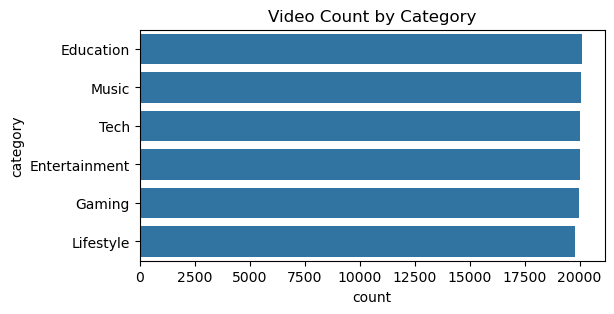

In [56]:
plt.figure(figsize=(6,3))
sns.countplot(
    y='category',
    data=data,
    order=data['category'].value_counts().index
)
plt.title("Video Count by Category")
plt.show()


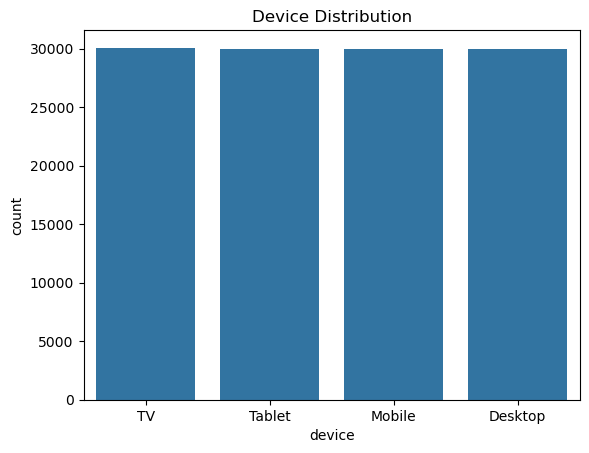

In [25]:
sns.countplot(x='device', data=data)
plt.title("Device Distribution")
plt.show()


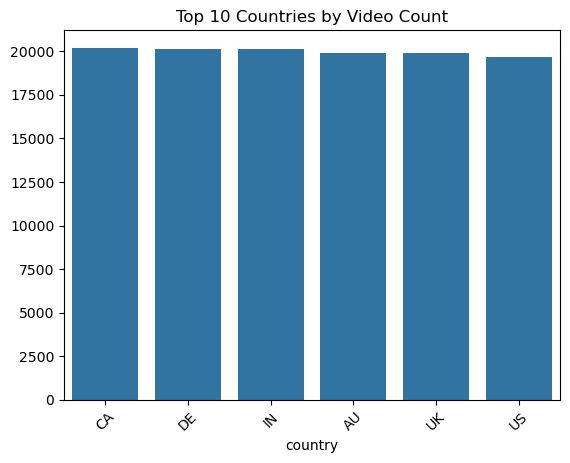

In [26]:
top_countries = data['country'].value_counts().head(10)

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Video Count")
plt.show()


In [27]:
# Categories, devices, and countries all have almost equal counts
# Most numeric variables show synthetic or near-uniform distributions.

In [28]:
# Numeric features exhibit synthetic, near-uniform distributions.


### Bi-Variate Analysis

In [29]:
# sns.scatterplot(
#     x='views',
#     y='ad_revenue_usd',
#     data=data,
#     alpha=0.3
# )
# plt.title("Views vs Ad Revenue")
# plt.show()


# Weak explanatory value 

In [30]:
# sns.scatterplot(
#     x='watch_time_minutes',
#     y='ad_revenue_usd',
#     data=data,
#     alpha=0.3
# )
# plt.title("Watch Time vs Ad Revenue")
# plt.show()

# Weak explanatory value 

In [31]:
# sns.scatterplot(
#     x='likes',
#     y='ad_revenue_usd',
#     data=data,
#     alpha=0.3
# )
# plt.title("Likes vs Ad Revenue")
# plt.show()

# Weak explanatory value compared to later plots

In [32]:
data['engagement_rate'] = (data['likes'] + data['comments']) / data['views']
data['watch_time_per_view'] = data['watch_time_minutes'] / data['views']

# Handle division-by-zero safely
data.replace([np.inf, -np.inf], 0, inplace=True)


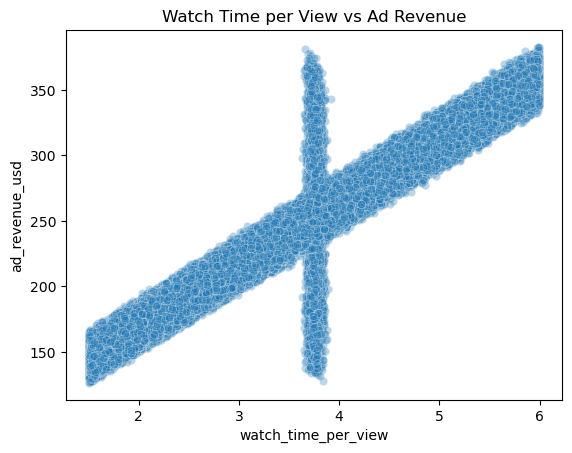

In [33]:
sns.scatterplot(
    x='watch_time_per_view',
    y='ad_revenue_usd',
    data=data,
    alpha=0.3
)
plt.title("Watch Time per View vs Ad Revenue")
plt.show()


In [34]:
# plt.figure(figsize=(10,4))
# sns.boxplot(
#     x='category',
#     y='ad_revenue_usd',
#     data=data
# )
# plt.xticks(rotation=45)
# plt.title("Ad Revenue by Category")
# plt.show()



# Category and device show overlapping revenue distributions,
# indicating weak standalone predictive power.

In [35]:
# sns.boxplot(
#     x='device',
#     y='ad_revenue_usd',
#     data=data
# )
# plt.title("Ad Revenue by Device")
# plt.show()



# Device is likely noise, but still okay to encode (model will downweight it).

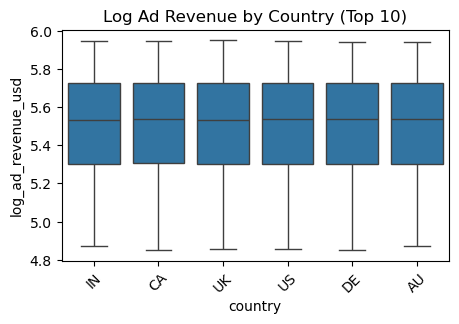

In [57]:
top_countries = data['country'].value_counts().head(10).index

plt.figure(figsize=(5,3))
sns.boxplot(
    x='country',
    y='log_ad_revenue_usd',
    data=data[data['country'].isin(top_countries)]
)
plt.xticks(rotation=45)
plt.title("Log Ad Revenue by Country (Top 10)")
plt.show()


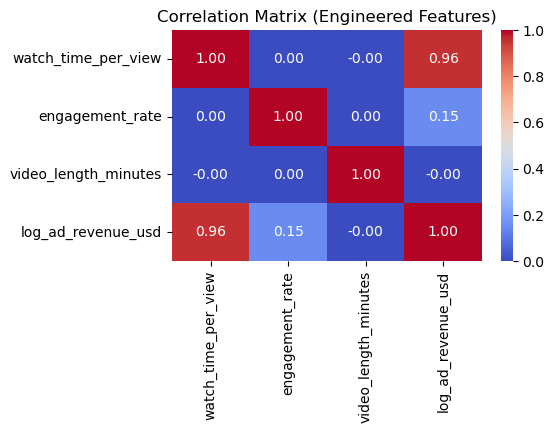

In [58]:
# correlation heatmap 
corr_features = [
    'watch_time_per_view',
    'engagement_rate',
    'video_length_minutes',
    'log_ad_revenue_usd'
]
corr = data[corr_features].corr()
plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix (Engineered Features)")
plt.show()

In [38]:
## EDA Summary+

# Watch time per view is the strongest factor affecting ad revenue.

# Engagement rate has a weak effect when considered alone.

# Category, device, and country change revenue distribution, but none dominate by themselves.

# Raw metrics like views and watch time are redundant, so transformed features are more useful.


In [39]:
# EDA Technical Interpretation
# Viewer retention matters more than pure views for earning ad revenue.

# Watch time per view replaces raw watch time to remove redundancy and reduce correlation issues.

# Log transformations help stabilize relationships between features and revenue.

# Categorical features add context, but most predictive power comes from retention and reach.

In [40]:
# the watch_time_per_view has high impact on ad revenue(after log transform the relationship is stable) and is more than the log_views

In [41]:
# Dropping the redundant columns before modelling
target = 'log_ad_revenue_usd'
data_model = data.drop(columns=[
    'video_id',
    'date',
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'ad_revenue_usd'  
])
data_model = data_model.reset_index(drop=True)

print( data_model.shape)
print(data_model.info())

(120000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_length_minutes  120000 non-null  float64
 1   subscribers           120000 non-null  int64  
 2   category              120000 non-null  object 
 3   device                120000 non-null  object 
 4   country               120000 non-null  object 
 5   year                  120000 non-null  int32  
 6   month                 120000 non-null  int32  
 7   dayofweek             120000 non-null  int32  
 8   log_views             120000 non-null  float64
 9   log_subscribers       120000 non-null  float64
 10  log_ad_revenue_usd    120000 non-null  float64
 11  engagement_rate       120000 non-null  float64
 12  watch_time_per_view   120000 non-null  float64
dtypes: float64(6), int32(3), int64(1), object(3)
memory usage: 10.5+ MB
None


In [42]:
numeric_features = [
    'log_views',
    'log_subscribers',
    'watch_time_per_view',
    'engagement_rate',
    'video_length_minutes',
    'year',
    'month',
    'dayofweek'
]

categorical_features = [
    'category',
    'device',
    'country'
]


In [43]:
# train test split
from sklearn.model_selection import train_test_split

X = data_model.drop(columns=[target])
y = data_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)


In [45]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'RandomForest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model': name,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
results_df


,Model,R2,RMSE,MAE
4,RandomForest,0.949379,0.057512,0.015284
1,Ridge,0.938500,0.063391,0.035196
0,LinearRegression,0.938500,0.063391,0.035196
3,ElasticNet,0.937155,0.064080,0.035301
2,Lasso,0.934007,0.065665,0.036701


In [47]:

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models['RandomForest'])
])

best_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
# Random Forest outperformed linear models, indicating non-linear
# relationships between engagement metrics and ad revenue.


In [49]:
# Numeric feature names (unchanged)
numeric_features = [
    'log_views',
    'log_subscribers',
    'watch_time_per_view',
    'engagement_rate',
    'video_length_minutes',
    'year',
    'month',
    'dayofweek'
]

# Get encoded categorical feature names
encoded_cat_features = (
    best_pipeline
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(['category', 'device', 'country'])
)

# Combine all feature names
feature_names = numeric_features + list(encoded_cat_features)


In [50]:
# Extract feature importances
importances = best_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)


,Feature,Importance
2,watch_time_per_view,0.934325
3,engagement_rate,0.029881
0,log_views,0.007638
1,log_subscribers,0.006651
4,video_length_minutes,0.006571
6,month,0.003051
7,dayofweek,0.002518
15,device_Mobile,0.000616
14,device_Desktop,0.000608
23,country_US,0.000601


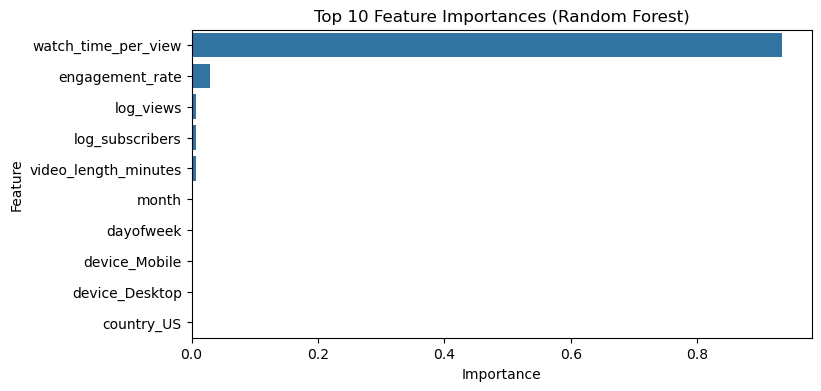

In [59]:
plt.figure(figsize=(8,4))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


In [52]:
import joblib

joblib.dump(best_pipeline, "youtube_ad_revenue_model.pkl")


['youtube_ad_revenue_model.pkl']

In [53]:
loaded_model = joblib.load("youtube_ad_revenue_model.pkl")

# test prediction on a few rows
loaded_model.predict(X_test.iloc[:5])


array([5.86948292, 5.83833542, 5.32398565, 5.17963693, 5.60429255])

In [54]:
joblib.dump({
    "numeric_features": numeric_features,
    "categorical_features": categorical_features
}, "feature_config.pkl")


['feature_config.pkl']

In [55]:
from joblib import load
m = load("youtube_ad_revenue_model.pkl")
print(type(m))
try:
    print("Model repr:", m)
    # If pipeline or ColumnTransformer:
    if hasattr(m, "named_steps"):
        print("Pipeline steps:", m.named_steps.keys())
    if hasattr(m, "get_params"):
        print("Params keys sample:", list(m.get_params().keys())[:20])
except Exception as e:
    print("Inspect error:", e)


<class 'sklearn.pipeline.Pipeline'>
Model repr: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['log_views',
                                                   'log_subscribers',
                                                   'watch_time_per_view',
                                                   'engagement_rate',
                                                   'video_length_minutes',
                                                   'year', 'month',
                                                   'dayofweek']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['category', 'device',
                                                   '